In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [8]:
df = pd.read_csv(
    r"C:\Users\malini\OneDrive\Documents\GitHub\solar-panel---regression\data\solarpowergeneration.csv"
)

print(df.head())

   distance-to-solar-noon  temperature  wind-direction  wind-speed  sky-cover  \
0                0.859897           69              28         7.5          0   
1                0.628535           69              28         7.5          0   
2                0.397172           69              28         7.5          0   
3                0.165810           69              28         7.5          0   
4                0.065553           69              28         7.5          0   

   visibility  humidity  average-wind-speed-(period)  \
0        10.0        75                          8.0   
1        10.0        77                          5.0   
2        10.0        70                          0.0   
3        10.0        33                          0.0   
4        10.0        21                          3.0   

   average-pressure-(period)  power-generated  
0                      29.82                0  
1                      29.85                0  
2                      29.89    

In [9]:
# Rename columns for easier access
df.rename(columns={
    "distance-to-solar-noon": "distance_to_solar_noon",
    "wind-direction": "wind_direction",
    "wind-speed": "wind_speed",
    "sky-cover": "sky_cover",
    "average-wind-speed-(period)": "average_wind_speed",
    "average-pressure-(period)": "average_pressure",
    "power-generated": "power_generated"
}, inplace=True)

In [10]:
# Handle missing value in average_wind_speed by filling with median
df['average_wind_speed'].fillna(df['average_wind_speed'].median(), inplace=True)

C:\Users\malini\AppData\Local\Temp\ipykernel_12732\2660599894.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['average_wind_speed'].fillna(df['average_wind_speed'].median(), inplace=True)


0        8.0
1        5.0
2        0.0
3        0.0
4        3.0
        ... 
2915    10.0
2916    15.0
2917    21.0
2918    17.0
2919    11.0
Name: average_wind_speed, Length: 2920, dtype: float64

In [11]:
# Set seaborn style
sns.set_style("whitegrid")

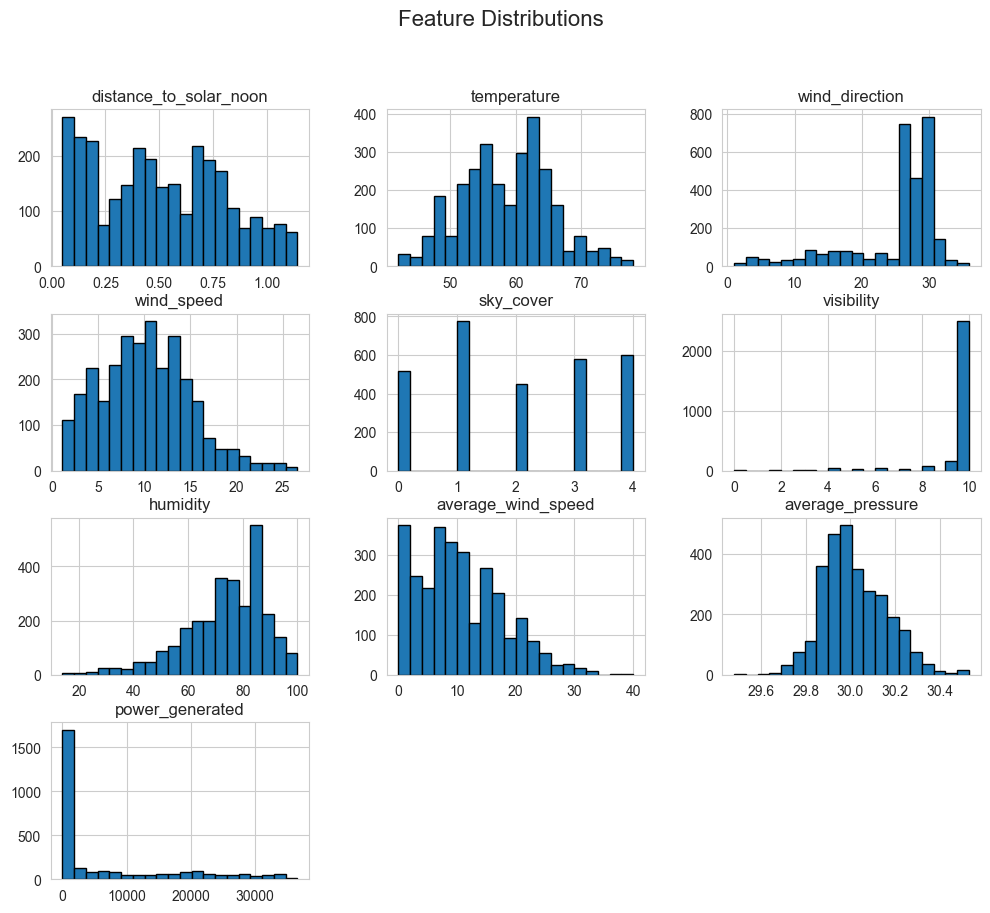

In [12]:
# 1. Histograms for numerical variables
df.hist(figsize=(12, 10), bins=20, edgecolor='black')
plt.suptitle("Feature Distributions", fontsize=16)
plt.show()

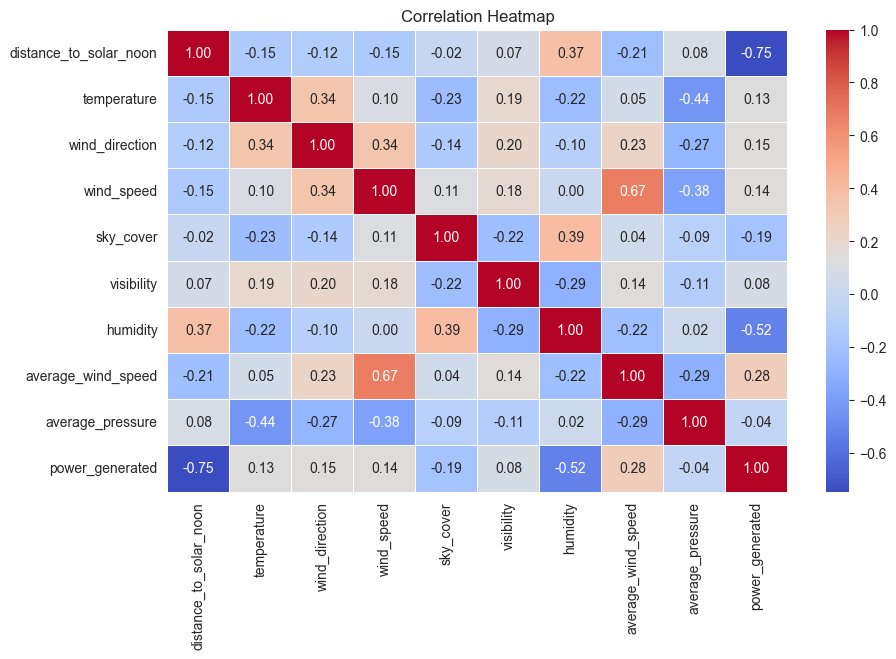

In [13]:
# 2. Correlation heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

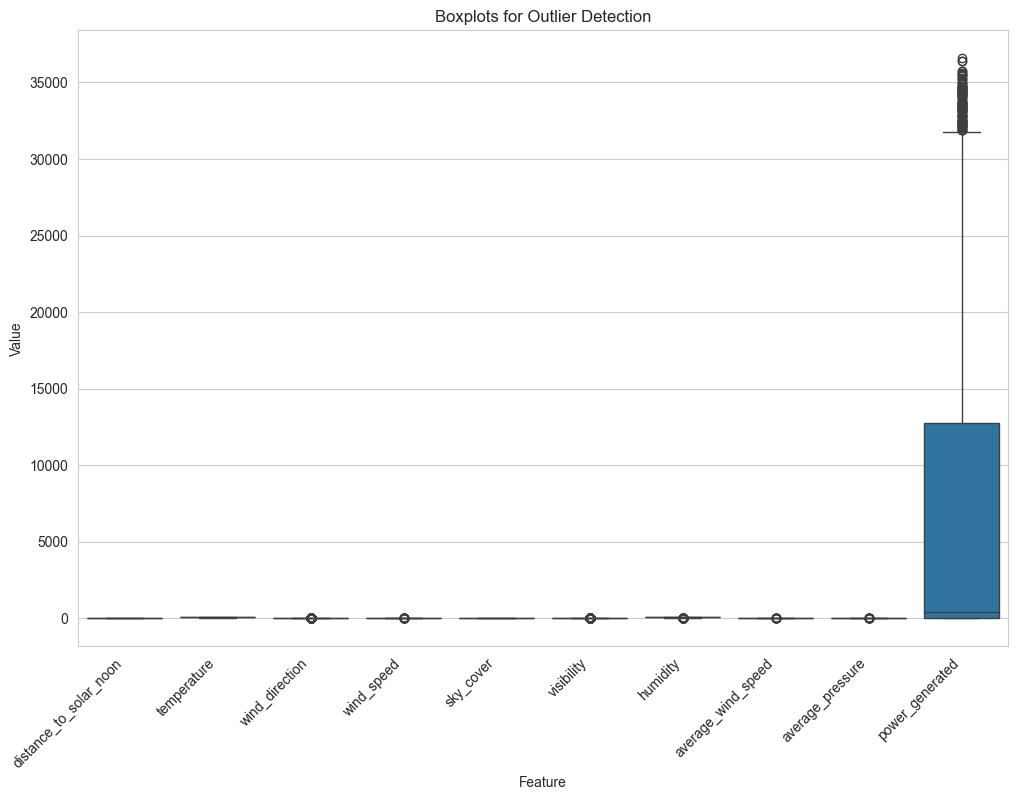

: 

In [14]:
# 3. Boxplots to detect outliers
plt.figure(figsize=(12, 8))
df_melted = df.melt(var_name="Feature", value_name="Value")
sns.boxplot(x="Feature", y="Value", data=df_melted)
plt.xticks(rotation=45, ha='right')
plt.title("Boxplots for Outlier Detection")
plt.show()